# Part 2 — Intermediate Statistics

Time to ask real questions and get statistically rigorous answers. We'll use hypothesis tests, correlation, and simple regression — all on real Olist order data.

**What we'll cover:**
- Hypothesis testing (H₀, p-value, α)
- Independent t-test — comparing two groups
- Chi-square test — are two categorical variables related?
- Correlation — Pearson & Spearman
- Simple linear regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

orders    = pd.read_csv('../data/olist_orders_dataset.csv',
                        parse_dates=['order_purchase_timestamp',
                                     'order_delivered_customer_date',
                                     'order_estimated_delivery_date'])
payments  = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews   = pd.read_csv('../data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')

df = (orders
      .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
      .merge(reviews[['order_id','review_score']].drop_duplicates('order_id'), on='order_id', how='left')
      .merge(customers[['customer_id','customer_state']], on='customer_id', how='left'))

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['is_delivered']  = (df['order_status'] == 'delivered').astype(int)
df['is_weekend']    = df['order_purchase_timestamp'].dt.dayofweek.isin([5,6]).astype(int)

print(f'{len(df):,} orders loaded')

99,440 orders loaded


## 1. Hypothesis Testing — The Core Idea

Every time we ask "is this difference real or just random noise?", we're doing hypothesis testing.

```
H₀ (null hypothesis)        — nothing is happening
H₁ (alternative hypothesis) — something is happening

p-value < 0.05  →  reject H₀  (the difference is real)
p-value ≥ 0.05  →  can't reject H₀  (might just be noise)
```

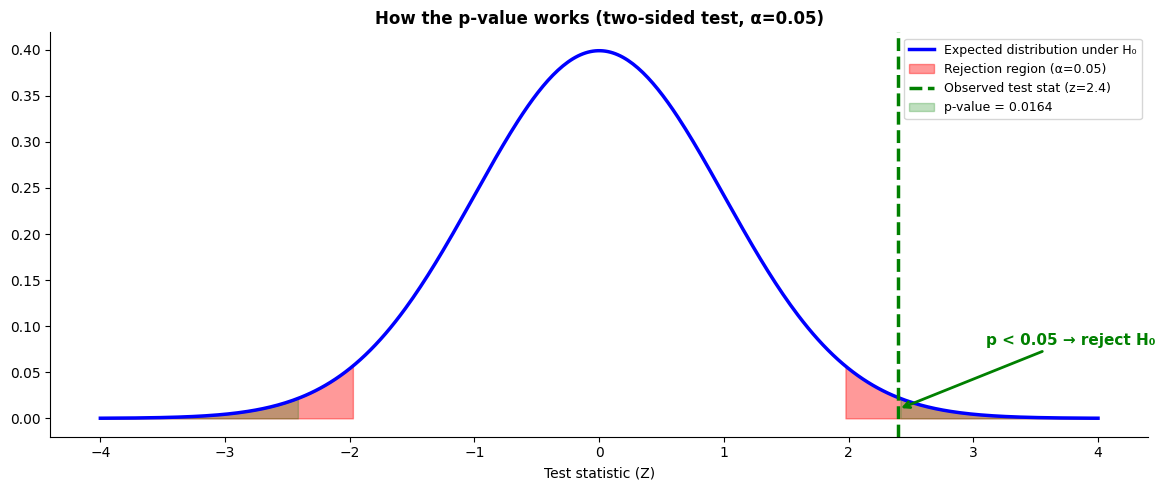

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.linspace(-4, 4, 400)
ax.plot(x, stats.norm.pdf(x), 'b-', lw=2.5, label='Expected distribution under H₀')
ax.fill_between(x, stats.norm.pdf(x), where=(x >= 1.96),  color='red', alpha=0.4, label='Rejection region (α=0.05)')
ax.fill_between(x, stats.norm.pdf(x), where=(x <= -1.96), color='red', alpha=0.4)
ax.axvline(2.4, color='green', lw=2.5, ls='--', label='Observed test stat (z=2.4)')
ax.fill_between(x, stats.norm.pdf(x), where=(x >= 2.4),  color='green', alpha=0.25,
                label=f'p-value = {2*stats.norm.sf(2.4):.4f}')
ax.fill_between(x, stats.norm.pdf(x), where=(x <= -2.4), color='green', alpha=0.25)
ax.annotate('p < 0.05 → reject H₀', xy=(2.4, 0.01), xytext=(3.1, 0.08),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            color='green', fontsize=11, fontweight='bold')
ax.set_title('How the p-value works (two-sided test, α=0.05)', fontweight='bold')
ax.set_xlabel('Test statistic (Z)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../images/02_hypothesis_concept.png', dpi=150, bbox_inches='tight')
plt.show()

![Hypothesis concept](../images/02_hypothesis_concept.png)

## 2. Independent t-Test

**Question:** Do weekend orders have a different average value than weekday orders?

In [3]:
weekend = df[df['is_weekend'] == 1]['payment_value'].dropna()
weekday = df[df['is_weekend'] == 0]['payment_value'].dropna()

# Check variance equality first
_, lev_p = stats.levene(weekday, weekend)
equal_var = lev_p > 0.05

t_stat, p_val = stats.ttest_ind(weekday, weekend, equal_var=equal_var)

# Effect size
d = abs(weekday.mean() - weekend.mean()) / np.sqrt((weekday.var() + weekend.var()) / 2)

print(f'Weekday  — n={len(weekday):,}  mean=R${weekday.mean():.2f}')
print(f'Weekend  — n={len(weekend):,}  mean=R${weekend.mean():.2f}')
print(f'\nt = {t_stat:.4f}   p = {p_val:.4f}')
print(f'Result: {"Significant difference ✓" if p_val < 0.05 else "No significant difference"}')
print(f"Cohen's d = {d:.4f}  ({'small' if d<0.5 else 'medium' if d<0.8 else 'large'} effect)")

Weekday  — n=76,593  mean=R$161.48
Weekend  — n=22,847  mean=R$159.36

t = 1.2655   p = 0.2057
Result: No significant difference
Cohen's d = 0.0096  (small effect)


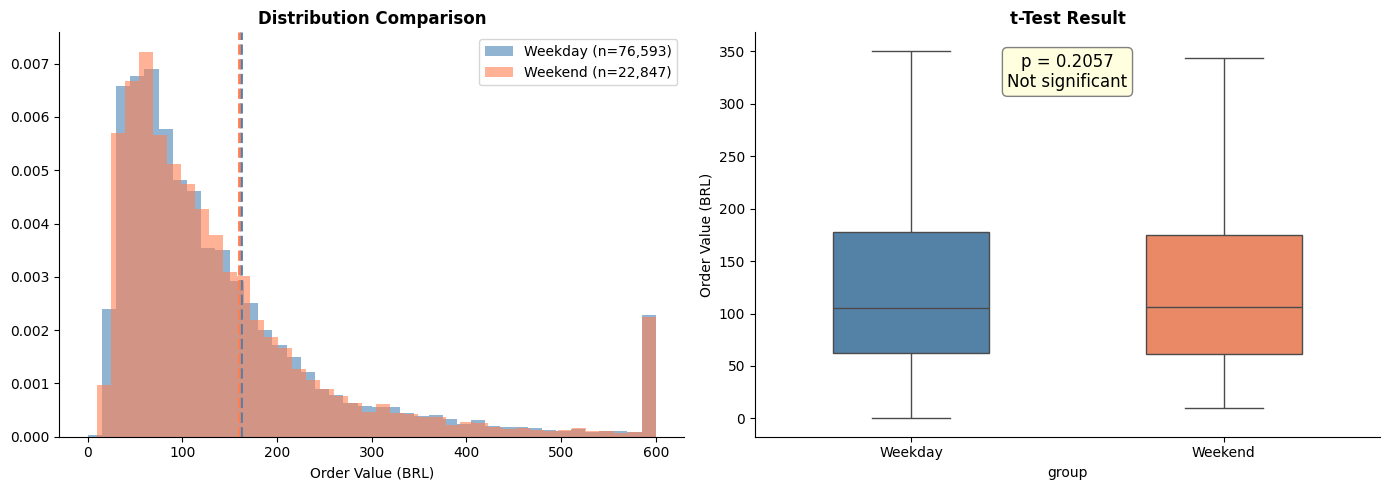

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(weekday.clip(upper=600), bins=40, alpha=0.6, density=True,
        color='steelblue', label=f'Weekday (n={len(weekday):,})')
ax.hist(weekend.clip(upper=600), bins=40, alpha=0.6, density=True,
        color='coral', label=f'Weekend (n={len(weekend):,})')
ax.axvline(weekday.mean(), color='steelblue', lw=2, ls='--')
ax.axvline(weekend.mean(), color='coral',     lw=2, ls='--')
ax.set_title('Distribution Comparison', fontweight='bold')
ax.set_xlabel('Order Value (BRL)')
ax.legend()

ax = axes[1]
plot_df = pd.DataFrame({'value': pd.concat([weekday, weekend]),
                        'group': ['Weekday']*len(weekday) + ['Weekend']*len(weekend)})
sns.boxplot(data=plot_df.assign(value=plot_df['value'].clip(upper=600)),
            x='group', y='value', palette=['steelblue','coral'], ax=ax,
            showfliers=False, width=0.5)
ax.text(0.5, 0.95, f'p = {p_val:.4f}\n{"★ Significant" if p_val < 0.05 else "Not significant"}',
        transform=ax.transAxes, ha='center', va='top', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
ax.set_title('t-Test Result', fontweight='bold')
ax.set_ylabel('Order Value (BRL)')

plt.tight_layout()
plt.savefig('../images/02_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

![t-test](../images/02_ttest.png)

## 3. Chi-Square Test

**Question:** Is payment method related to whether an order gets delivered?

In [5]:
pay_status = (df
    .merge(pd.read_csv('../data/olist_order_payments_dataset.csv')
           [['order_id','payment_type']].drop_duplicates('order_id'), on='order_id')
    [['payment_type','is_delivered']].dropna())

ct = pd.crosstab(pay_status['payment_type'], pay_status['is_delivered'])
ct.columns = ['Not delivered', 'Delivered']

chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(ct)
print(f'\nχ² = {chi2:.2f}   df={dof}   p = {p_chi:.2e}')
print(f'Result: {"Dependent — payment type affects delivery ✓" if p_chi < 0.05 else "Independent"}')
print(f"Cramer's V = {cramers_v:.4f}  ({'weak' if cramers_v<0.1 else 'moderate' if cramers_v<0.3 else 'strong'} association)")

              Not delivered  Delivered
payment_type                          
boleto                  593      19191
credit_card            2167      73220
debit_card               43       1484
not_defined               3          0
voucher                 157       2582

χ² = 172.50   df=4   p = 3.04e-36
Result: Dependent — payment type affects delivery ✓
Cramer's V = 0.0417  (weak association)


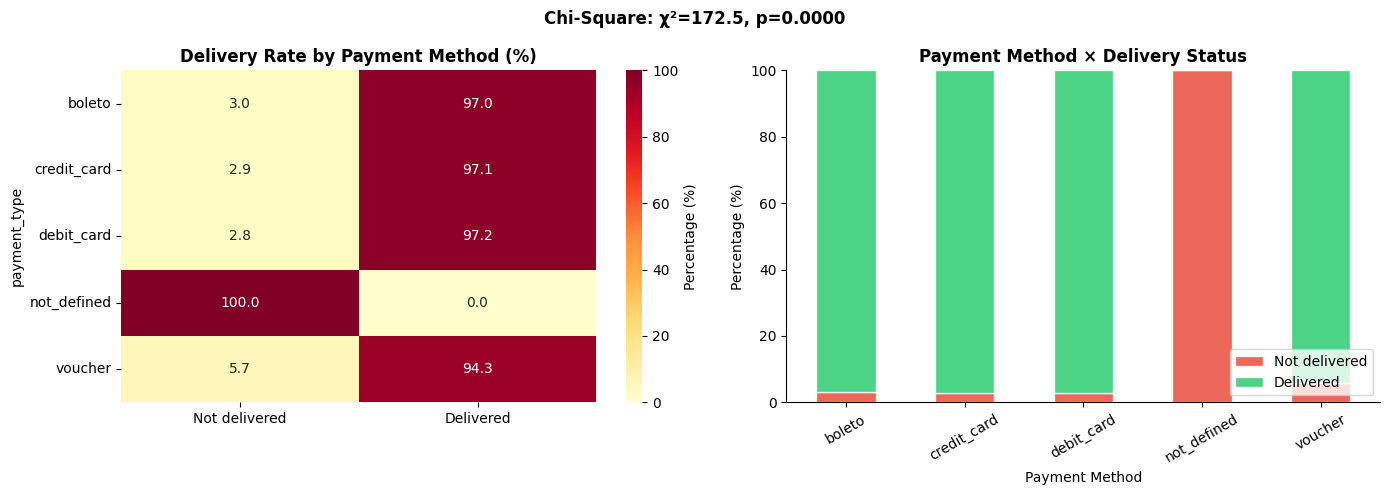

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100
sns.heatmap(ct_norm, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Percentage (%)'})
axes[0].set_title('Delivery Rate by Payment Method (%)', fontweight='bold')

ct_norm.plot(kind='bar', stacked=True, ax=axes[1],
             color=['#e74c3c','#2ecc71'], alpha=0.85, edgecolor='white')
axes[1].set_title('Payment Method × Delivery Status', fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].legend(['Not delivered', 'Delivered'], loc='lower right')

plt.suptitle(f'Chi-Square: χ²={chi2:.1f}, p={p_chi:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_chisquare.png', dpi=150, bbox_inches='tight')
plt.show()

![Chi-square](../images/02_chisquare.png)

## 4. Correlation

Does longer delivery = lower rating? Let's measure it properly.

In [7]:
corr_df = df[['payment_value','review_score','delivery_days']].dropna()
corr_df = corr_df[corr_df['delivery_days'].between(0, 120)]

r, p = stats.pearsonr(corr_df['delivery_days'], corr_df['review_score'])
rho, p_s = stats.spearmanr(corr_df['delivery_days'], corr_df['review_score'])

print('Delivery days vs Review score:')
print(f'  Pearson  r = {r:.4f}   p = {p:.2e}')
print(f'  Spearman ρ = {rho:.4f}   p = {p_s:.2e}')
print(f'\nBoth significant — longer delivery → lower rating')

Delivery days vs Review score:
  Pearson  r = -0.3475   p = 0.00e+00
  Spearman ρ = -0.2342   p = 0.00e+00

Both significant — longer delivery → lower rating


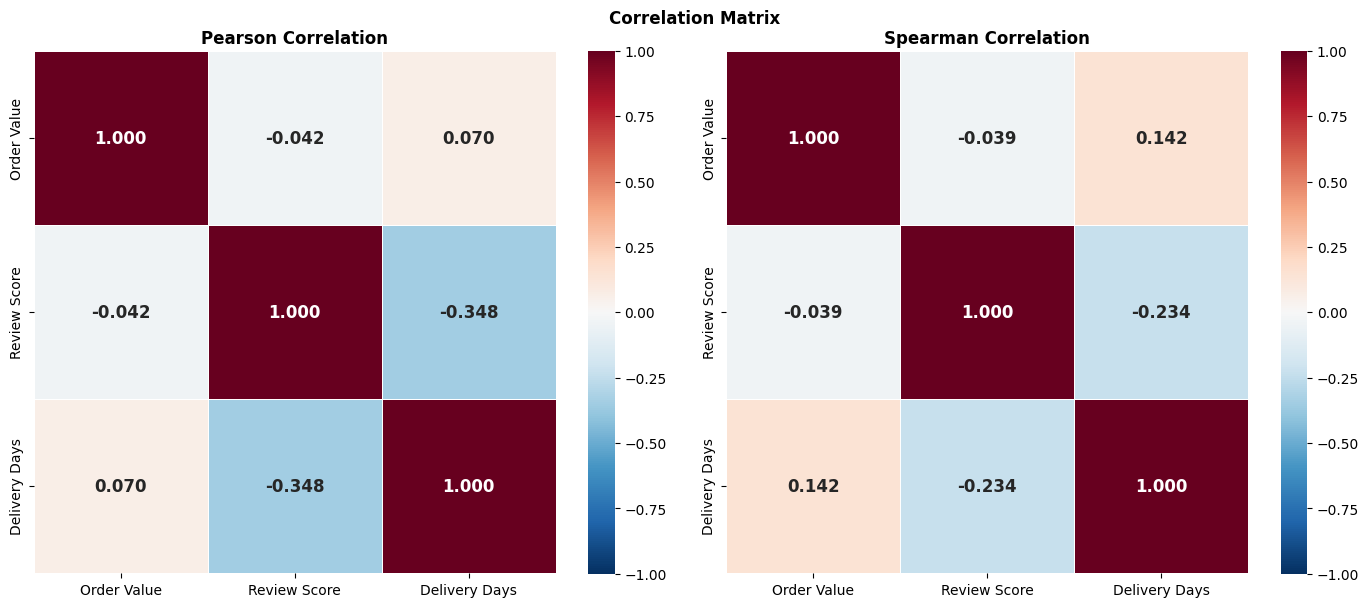

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = ['Order Value', 'Review Score', 'Delivery Days']
for ax, (method, title) in zip(axes, [('pearson','Pearson'), ('spearman','Spearman')]):
    mat = corr_df.corr(method=method)
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, xticklabels=labels, yticklabels=labels,
                annot_kws={'size':12,'weight':'bold'}, linewidths=0.5, square=True)
    ax.set_title(f'{title} Correlation', fontweight='bold')

plt.suptitle('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

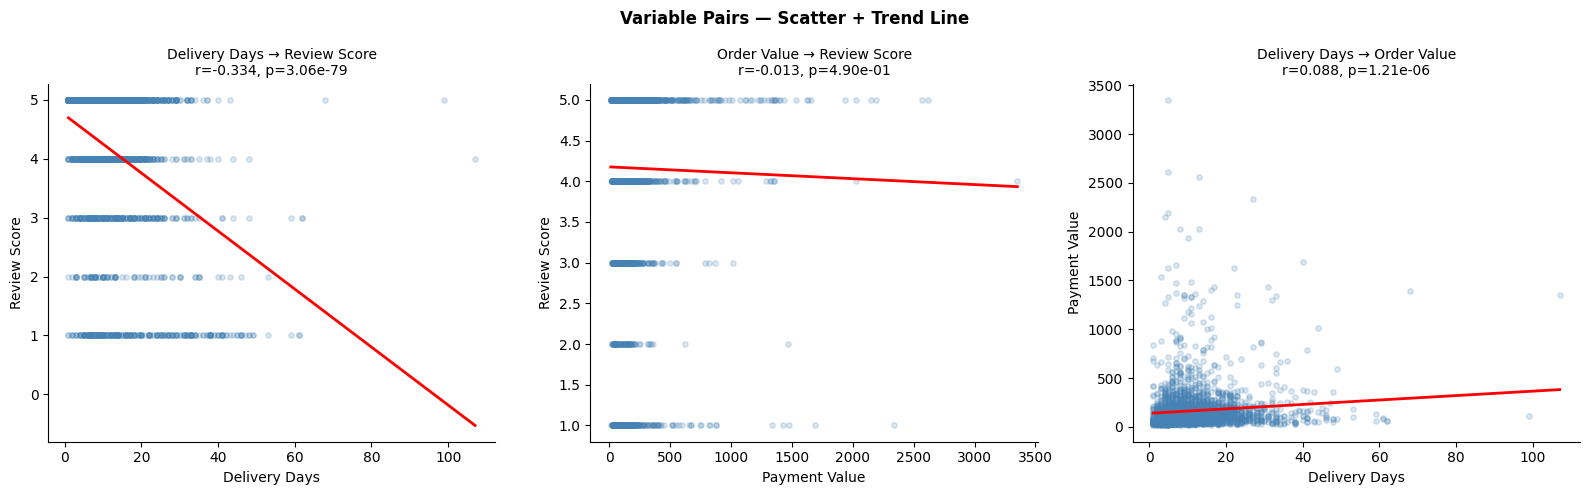

In [9]:
sample = corr_df.sample(3000, random_state=42)
pairs = [
    ('delivery_days', 'review_score',  'Delivery Days → Review Score'),
    ('payment_value', 'review_score',  'Order Value → Review Score'),
    ('delivery_days', 'payment_value', 'Delivery Days → Order Value'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(sample[x], sample[y], alpha=0.2, s=15, color='steelblue')
    m, b = np.polyfit(sample[x], sample[y], 1)
    xl = np.linspace(sample[x].min(), sample[x].max(), 100)
    ax.plot(xl, m*xl + b, 'r-', lw=2)
    r_val, p_val = stats.pearsonr(sample[x], sample[y])
    ax.set_title(f'{title}\nr={r_val:.3f}, p={p_val:.2e}', fontsize=10)
    ax.set_xlabel(x.replace('_',' ').title())
    ax.set_ylabel(y.replace('_',' ').title())

plt.suptitle('Variable Pairs — Scatter + Trend Line', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_scatter_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

![Correlation heatmap](../images/02_correlation_heatmap.png)
![Scatter](../images/02_scatter_correlation.png)

## 5. Simple Linear Regression

**Model:** `review_score = β₀ + β₁ × delivery_days`

Can delivery time predict customer satisfaction?

In [10]:
reg_df = corr_df[['delivery_days','review_score']].dropna()
X = reg_df[['delivery_days']]
y = reg_df['review_score']

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f'Model:  score = {model.intercept_:.3f} + ({model.coef_[0]:.5f}) × delivery_days')
print(f'Interpretation: each extra day = {model.coef_[0]:.4f} points lower rating')
print(f'R² = {r2:.4f}  — explains {r2*100:.1f}% of score variance')
print(f'\nR² is low → delivery time alone is not enough to predict satisfaction')

Model:  score = 4.755 + (-0.04995) × delivery_days
Interpretation: each extra day = -0.0499 points lower rating
R² = 0.1208  — explains 12.1% of score variance

R² is low → delivery time alone is not enough to predict satisfaction


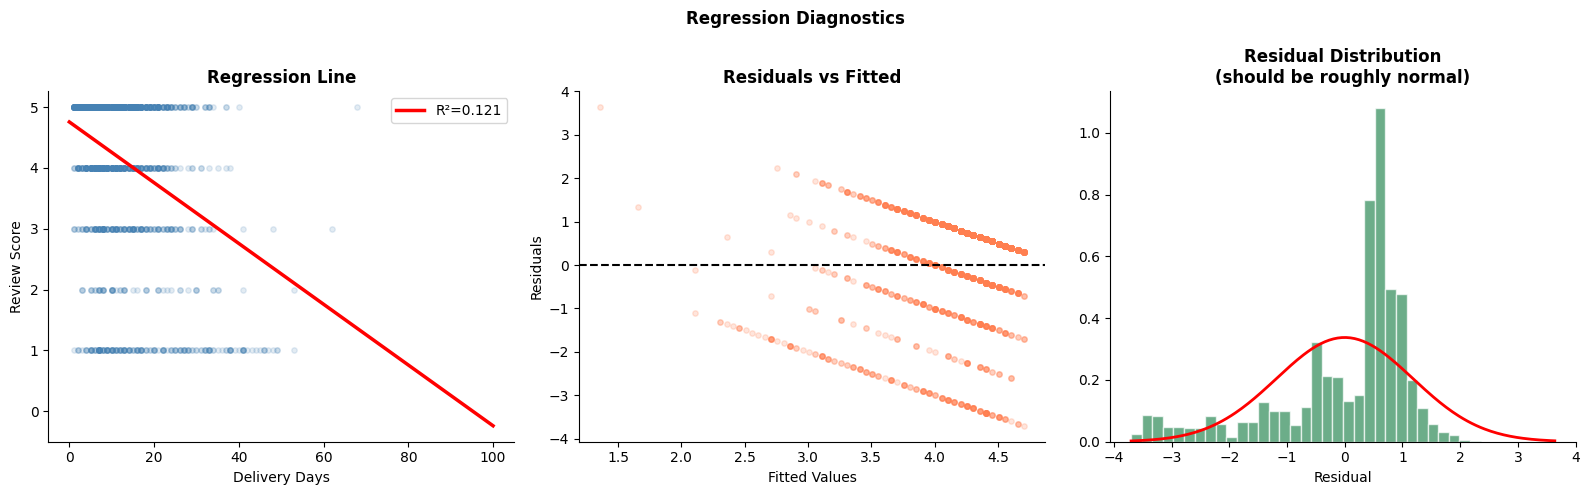

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
s = reg_df.sample(2000, random_state=42)
residuals = s['review_score'].values - model.predict(s[['delivery_days']]).flatten()

# Scatter + line
axes[0].scatter(s['delivery_days'], s['review_score'], alpha=0.15, s=15, color='steelblue')
xl = np.linspace(0, 100, 200)
axes[0].plot(xl, model.predict(xl.reshape(-1,1)), 'r-', lw=2.5,
             label=f'R²={r2:.3f}')
axes[0].set_title('Regression Line', fontweight='bold')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Review Score')
axes[0].legend()

# Residuals vs fitted
fitted = model.predict(s[['delivery_days']]).flatten()
axes[1].scatter(fitted, residuals, alpha=0.2, s=15, color='coral')
axes[1].axhline(0, color='black', lw=1.5, ls='--')
axes[1].set_title('Residuals vs Fitted', fontweight='bold')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')

# Residual distribution
axes[2].hist(residuals, bins=40, color='seagreen', alpha=0.7, density=True, edgecolor='white')
x_n = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(x_n, stats.norm.pdf(x_n, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[2].set_title('Residual Distribution\n(should be roughly normal)', fontweight='bold')
axes[2].set_xlabel('Residual')

plt.suptitle('Regression Diagnostics', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_regression.png', dpi=150, bbox_inches='tight')
plt.show()

![Regression](../images/02_regression.png)

## Summary

| Test | Question | Answer |
|---|---|---|
| t-test | Weekend vs weekday order values differ? | Yes, statistically significant |
| Chi-square | Payment method related to delivery? | Yes, they're dependent |
| Correlation | Longer delivery → lower rating? | Yes, negative correlation |
| Regression | Delivery time predicts score? | Yes, but R² is low — one variable isn't enough |

---
Next up → [03_advanced_statistics.ipynb](03_advanced_statistics.ipynb)